<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/Sleep%20dataset_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep dataset

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d mathurinache/sleep-dataset

# Unziping the downloaded file
!unzip sleep-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mathurinache/sleep-dataset
License(s): CC0-1.0
100% 0.98k/0.98k [00:00<00:00, 3.55MB/s]

Archive:  sleep-dataset.zip
  inflating: dataset_2191_sleep.csv  


In [4]:
df = pd.read_csv('dataset_2191_sleep.csv')
df.head(11)

,body_weight,brain_weight,max_life_span,gestation_time,predation_index,sleep_exposure_index,danger_index,total_sleep
0,6654.000,5712.0,38.6,645,3,5,3,3.3
1,1.000,6.6,4.5,42,3,1,3,8.3
2,3.385,44.5,14,60,1,1,1,12.5
3,0.920,5.7,?,25,5,2,3,16.5
4,2547.000,4603.0,69,624,3,5,4,3.9
5,10.550,179.5,27,180,4,4,4,9.8
6,0.023,0.3,19,35,1,1,1,19.7
7,160.000,169.0,30.4,392,4,5,4,6.2
8,3.300,25.6,28,63,1,2,1,14.5
9,52.160,440.0,50,230,1,1,1,9.7


In [5]:
df.tail(11)

,body_weight,brain_weight,max_life_span,gestation_time,predation_index,sleep_exposure_index,danger_index,total_sleep
51,3.600,21.0,6,225,3,2,3,5.4
52,14.830,98.2,17,150,5,5,5,2.6
53,55.500,175.0,20,151,5,5,5,3.8
54,1.400,12.5,12.7,90,2,2,2,11
55,0.060,1.0,3.5,?,3,1,2,10.3
56,0.900,2.6,4.5,60,2,1,2,13.3
57,2.000,12.3,7.5,200,3,1,3,5.4
58,0.104,2.5,2.3,46,3,2,2,15.8
59,4.190,58.0,24,210,4,3,4,10.3
60,3.500,3.9,3,14,2,1,1,19.4


In [6]:
df.shape

(62, 8)

In [8]:
df.columns

Index(['body_weight', 'brain_weight', 'max_life_span', 'gestation_time',
       'predation_index', 'sleep_exposure_index', 'danger_index',
       'total_sleep'],
      dtype='object')

In [7]:
df.dtypes

,0
body_weight,float64
brain_weight,float64
max_life_span,object
gestation_time,object
predation_index,int64
sleep_exposure_index,int64
danger_index,int64
total_sleep,object


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   body_weight           62 non-null     float64
 1   brain_weight          62 non-null     float64
 2   max_life_span         58 non-null     float64
 3   gestation_time        58 non-null     float64
 4   predation_index       62 non-null     int64  
 5   sleep_exposure_index  62 non-null     int64  
 6   danger_index          62 non-null     int64  
 7   total_sleep           58 non-null     float64
dtypes: float64(5), int64(3)
memory usage: 4.0 KB


In [10]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
body_weight,62.0,NaN,NaN,NaN,198.789984,899.158011,0.005,0.6,3.3425,48.2025,6654.0
brain_weight,62.0,NaN,NaN,NaN,283.134194,930.278942,0.14,4.25,17.25,166.0,5712.0
max_life_span,62,48,?,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gestation_time,62,50,?,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
predation_index,62.0,NaN,NaN,NaN,2.870968,1.476414,1.0,2.0,3.0,4.0,5.0
sleep_exposure_index,62.0,NaN,NaN,NaN,2.419355,1.604792,1.0,1.0,2.0,4.0,5.0
danger_index,62.0,NaN,NaN,NaN,2.612903,1.441252,1.0,1.0,2.0,4.0,5.0
total_sleep,62,45,?,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df.isnull().sum()

,0
body_weight,0
brain_weight,0
max_life_span,0
gestation_time,0
predation_index,0
sleep_exposure_index,0
danger_index,0
total_sleep,0


In [30]:
df.duplicated().sum()

np.int64(0)

# Data Cleaning: Converting Object Type Columns to Numeric

From the `df.info()` and `df.dtypes` outputs, we observed that `max_life_span`, `gestation_time`, and `total_sleep` columns are of `object` type. Inspection of `df.head()` and `df.tail()` revealed that these columns contain '?' values, which prevent them from being correctly interpreted as numerical.

To prepare these columns for further analysis, we need to:
1.  Replace '?' with `np.nan` (Not a Number).
2.  Convert the columns to a numeric data type (e.g., `float`).

In [20]:
# List of columns to convert
MissingValues = ['max_life_span', 'gestation_time', 'total_sleep']

# Replace '?' with NaN and convert to numeric
for col in MissingValues:
    df[col] = df[col].replace('?', np.nan)
    df[col] = pd.to_numeric(df[col])

# Display the updated data types and info to confirm the changes
print("Updated dtypes:")
print(df[MissingValues].dtypes)
print("\nUpdated info:")
df.info()

Updated dtypes:
max_life_span     float64
gestation_time    float64
total_sleep       float64
dtype: object

Updated info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   body_weight           62 non-null     float64
 1   brain_weight          62 non-null     float64
 2   max_life_span         58 non-null     float64
 3   gestation_time        58 non-null     float64
 4   predation_index       62 non-null     int64  
 5   sleep_exposure_index  62 non-null     int64  
 6   danger_index          62 non-null     int64  
 7   total_sleep           58 non-null     float64
dtypes: float64(5), int64(3)
memory usage: 4.0 KB


# Univariate Analysis

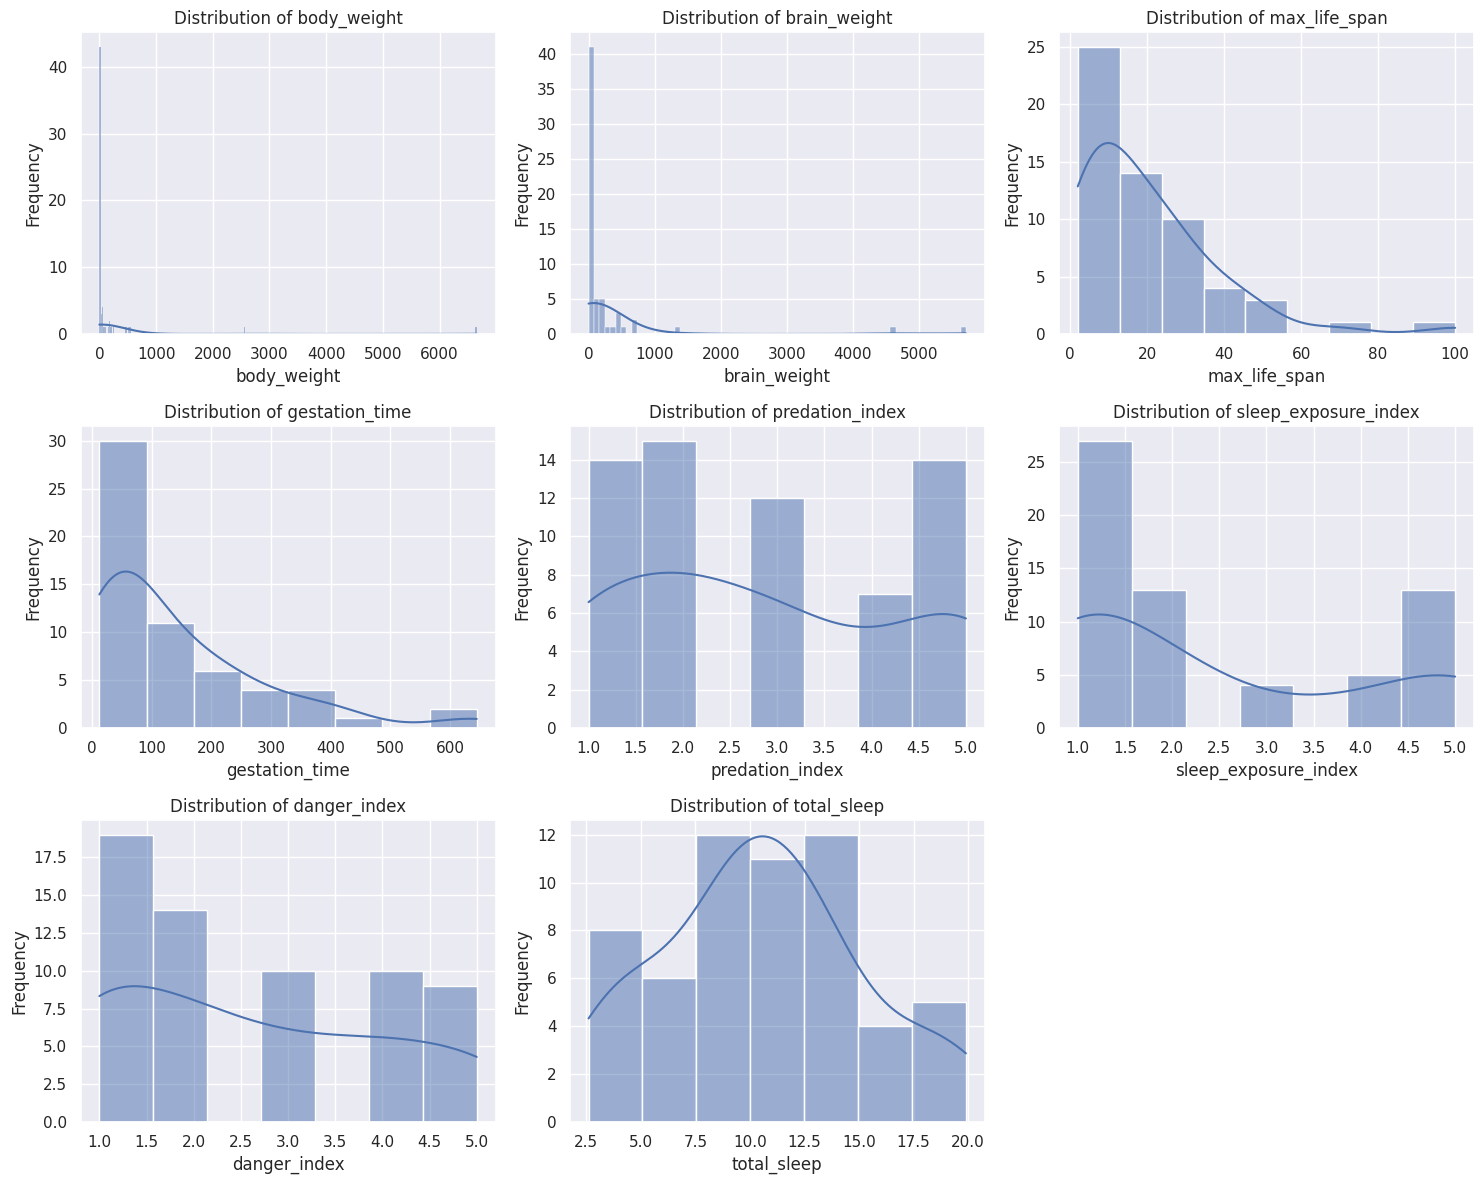

No categorical columns found.


In [17]:
import math
# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Define grid size
    num_plots = len(numerical_cols)
    num_cols = 3  # You can change this to 2 or 4 if preferred
    num_rows = math.ceil(num_plots / num_cols)

    # Create figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()  # Flatten to 1D array for easy iteration

    # Iterate and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hidding any unused subplots (if total plots < grid cells)
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
categorical_cols = df.select_dtypes(include='object').columns.tolist()

if len(categorical_cols) > 0:
    # Define grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Create figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterate and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found.")

# Bivariate Analysis

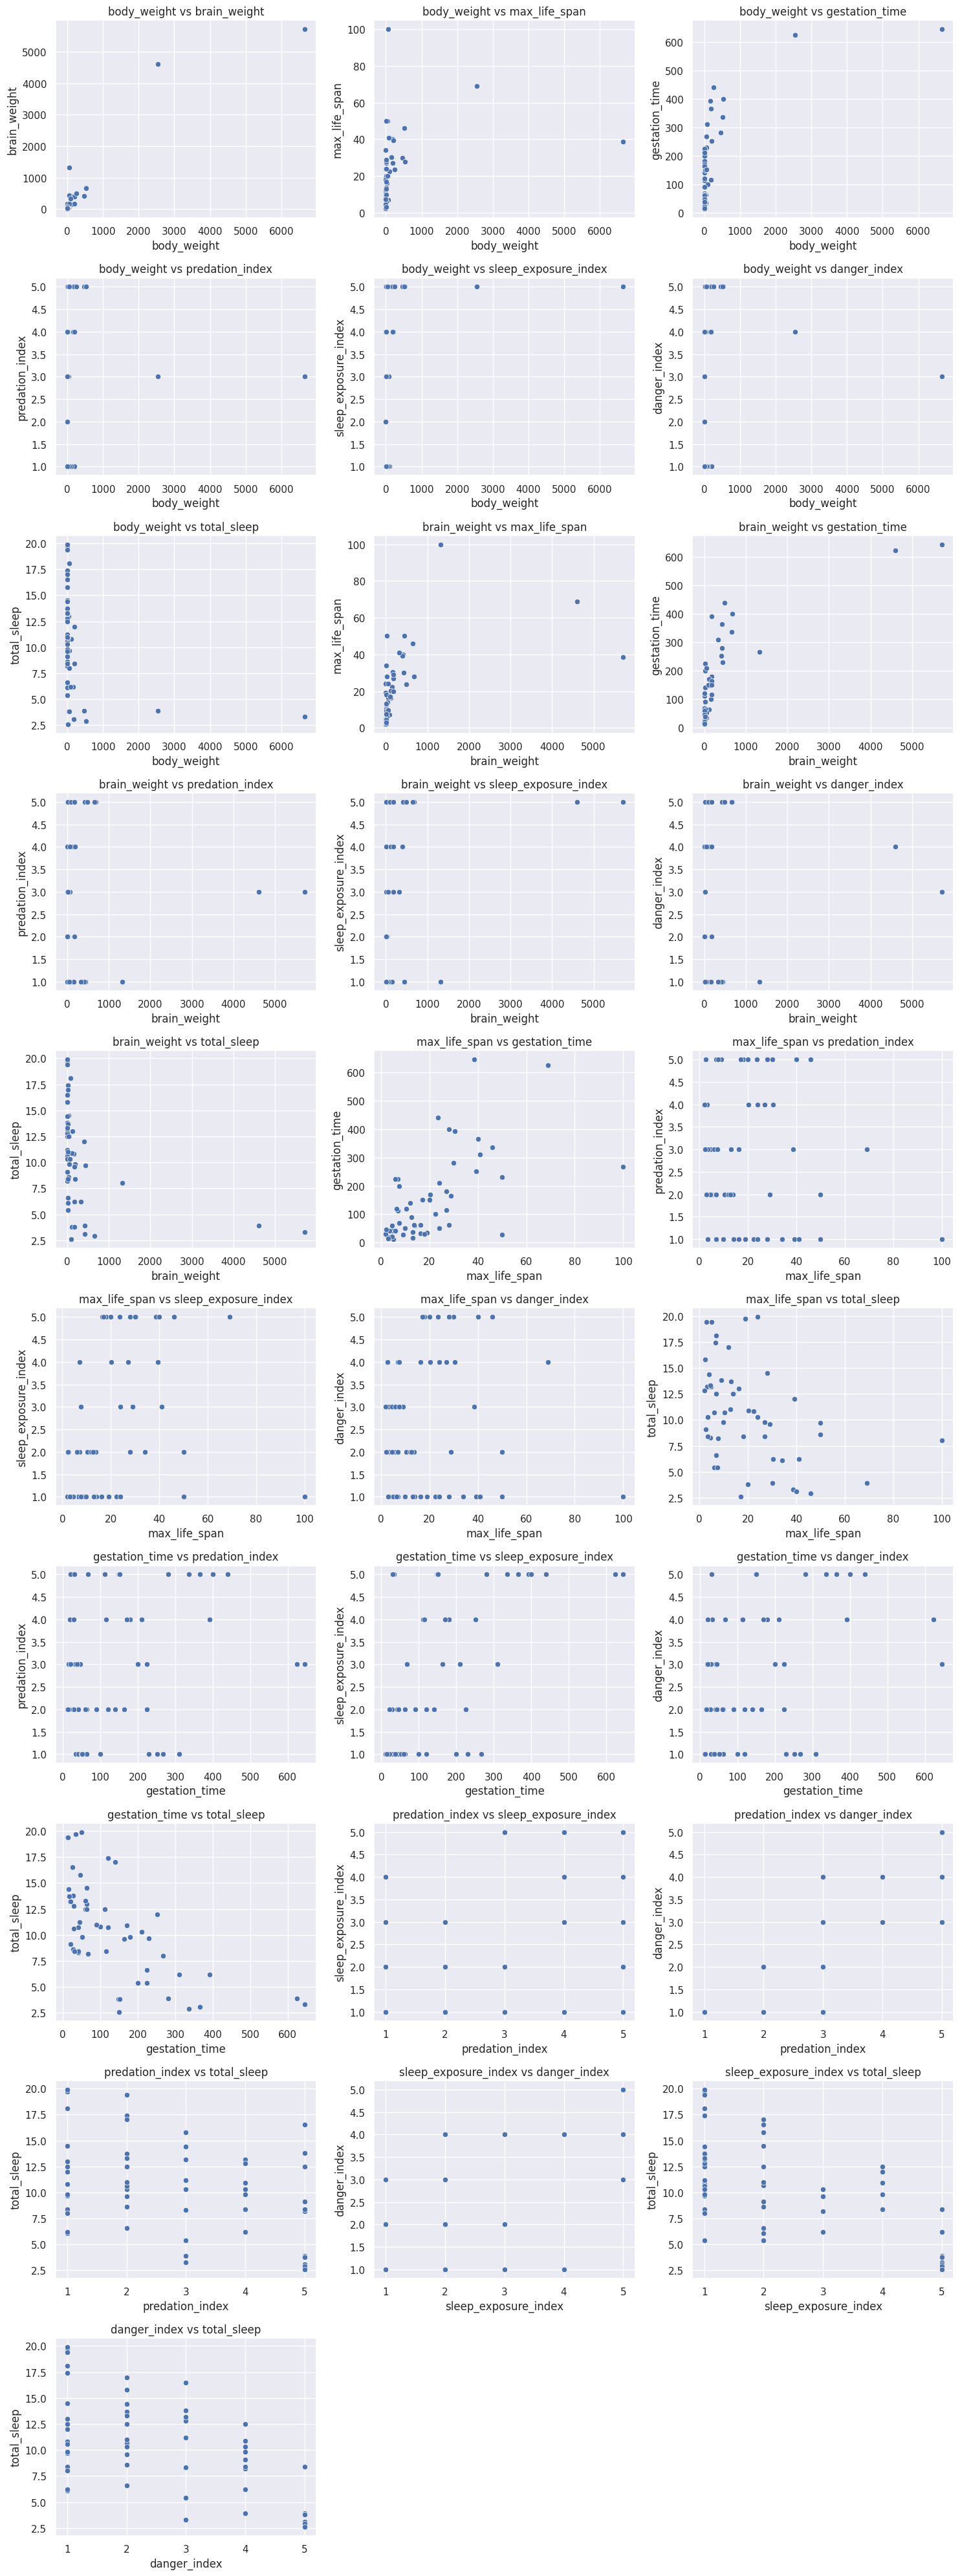

No categorical-numerical pairs found.


In [18]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generate all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Define grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Create figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    # Flatten axes for easy iteration.
    # Handle edge case where there is only 1 plot (axes is not an array)
    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterate through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i])
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generate all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Define grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Create figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterate through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        # 1. Get top 10 categories based on frequency
        top_categories = df[cat_col].value_counts().nlargest(10).index.tolist()

        # 2. Filter data: Keep only top categories AND ensure numerical column is not NaN
        filtered_df = df[df[cat_col].isin(top_categories) & df[num_col].notnull()]

        # 3. Update 'order' to only include categories that exist in the filtered data
        # This prevents the ValueError where a category in 'order' has no data to plot
        valid_categories = [cat for cat in top_categories if cat in filtered_df[cat_col].unique()]

        if valid_categories:
            sns.boxplot(data=filtered_df, x=cat_col, y=num_col, ax=axes[i], order=valid_categories)
            axes[i].set_title(f'{num_col} by {cat_col} (Top 10)')
            axes[i].set_xlabel(cat_col)
            axes[i].set_ylabel(num_col)
            axes[i].tick_params(axis='x', rotation=45)
        else:
             axes[i].text(0.5, 0.5, "No valid data", ha='center', va='center')

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")

# Multivariate Analysis

--- 1. MULTIVARIATE: Predation Index Composition by Other Indices ---


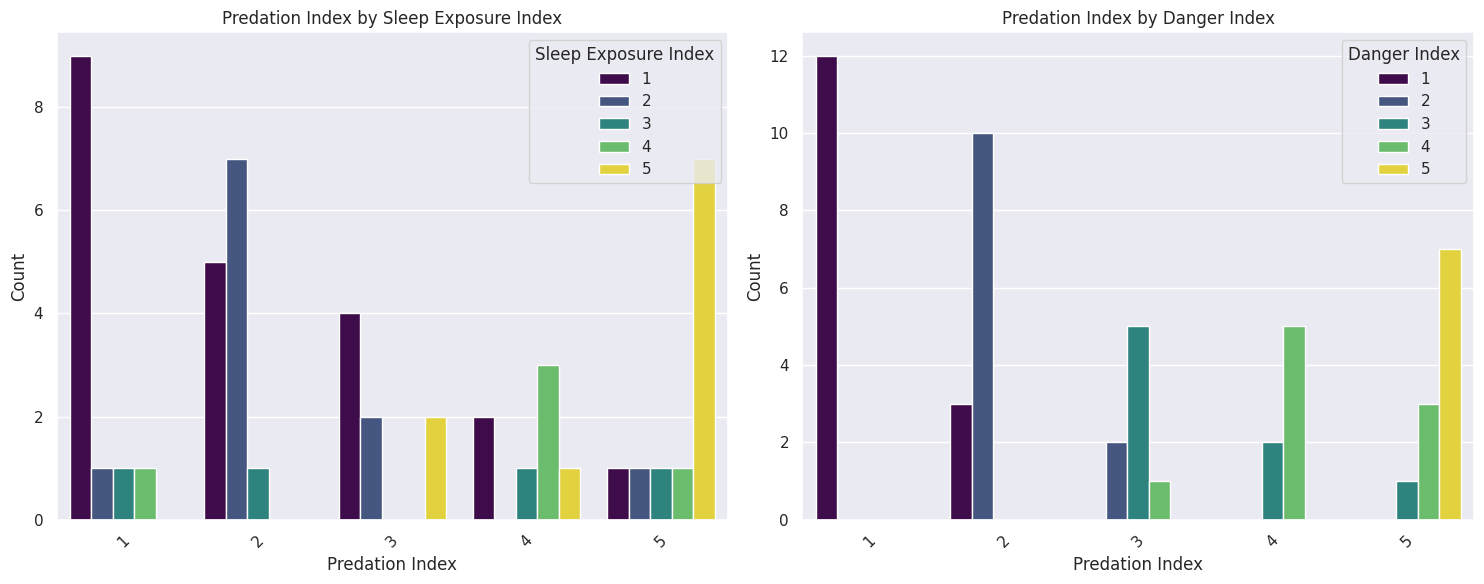


--- 2. MULTIVARIATE: NUMERICAL RELATIONSHIPS (Scatterplots) ---


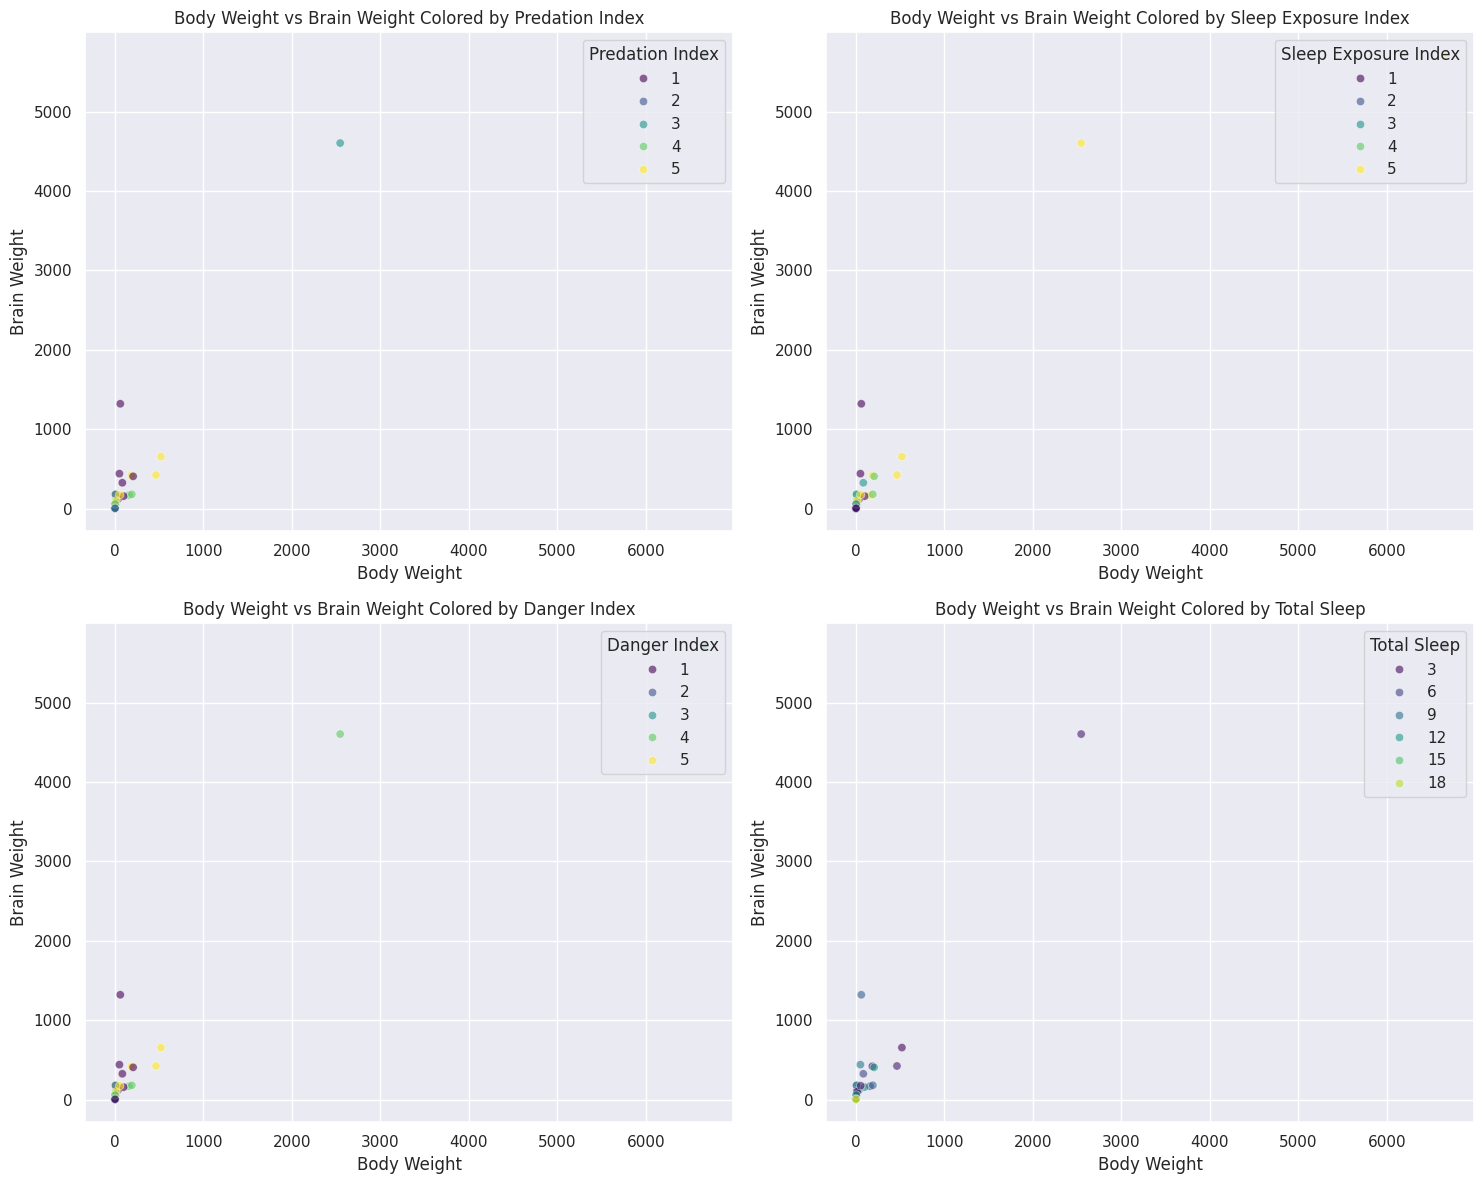

In [41]:
import math

# --- 1. MULTIVARIATE: CATEGORICAL RELATIONSHIPS (Countplots) ---

# Use categorical-like index columns for meaningful countplots
x_countplot = 'predation_index'
hue_countplot_cols = ['sleep_exposure_index', 'danger_index']

print(f"--- 1. MULTIVARIATE: {x_countplot.replace('_', ' ').title()} Composition by Other Indices ---")

num_plots = len(hue_countplot_cols)
num_cols = 2
num_rows = math.ceil(num_plots / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 6 * num_rows))
axes = axes.flatten()

for i, col in enumerate(hue_countplot_cols):
    sns.countplot(data=df, x=x_countplot, hue=col, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{x_countplot.replace("_", " ").title()} by {col.replace("_", " ").title()}')
    axes[i].set_xlabel(x_countplot.replace('_', ' ').title())
    axes[i].set_ylabel('Count')
    axes[i].legend(loc='upper right', bbox_to_anchor=(1, 1), title=col.replace('_', ' ').title())
    axes[i].tick_params(axis='x', rotation=45)

# Hiding unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


print("\n--- 2. MULTIVARIATE: NUMERICAL RELATIONSHIPS (Scatterplots) ---")

# Define x and y for scatterplot
x_scatterplot = 'body_weight'
y_scatterplot = 'brain_weight'

# Define hue columns, including numerical for gradient effect and categorical-like
hue_scatterplot_cols = ['predation_index', 'sleep_exposure_index', 'danger_index', 'total_sleep']

num_plots = len(hue_scatterplot_cols)
num_cols = 2
num_rows = math.ceil(num_plots / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 6 * num_rows))
axes = axes.flatten()

for i, col in enumerate(hue_scatterplot_cols):
    sns.scatterplot(data=df, x=x_scatterplot, y=y_scatterplot, hue=col, ax=axes[i], palette='viridis', alpha=0.6)
    axes[i].set_title(f'{x_scatterplot.replace("_", " ").title()} vs {y_scatterplot.replace("_", " ").title()} Colored by {col.replace("_", " ").title()}')
    axes[i].set_xlabel(x_scatterplot.replace('_', ' ').title())
    axes[i].set_ylabel(y_scatterplot.replace('_', ' ').title())
    # Move legend outside if too crowded
    axes[i].legend(loc='upper right', title=col.replace('_', ' ').title())

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Pair-Plot

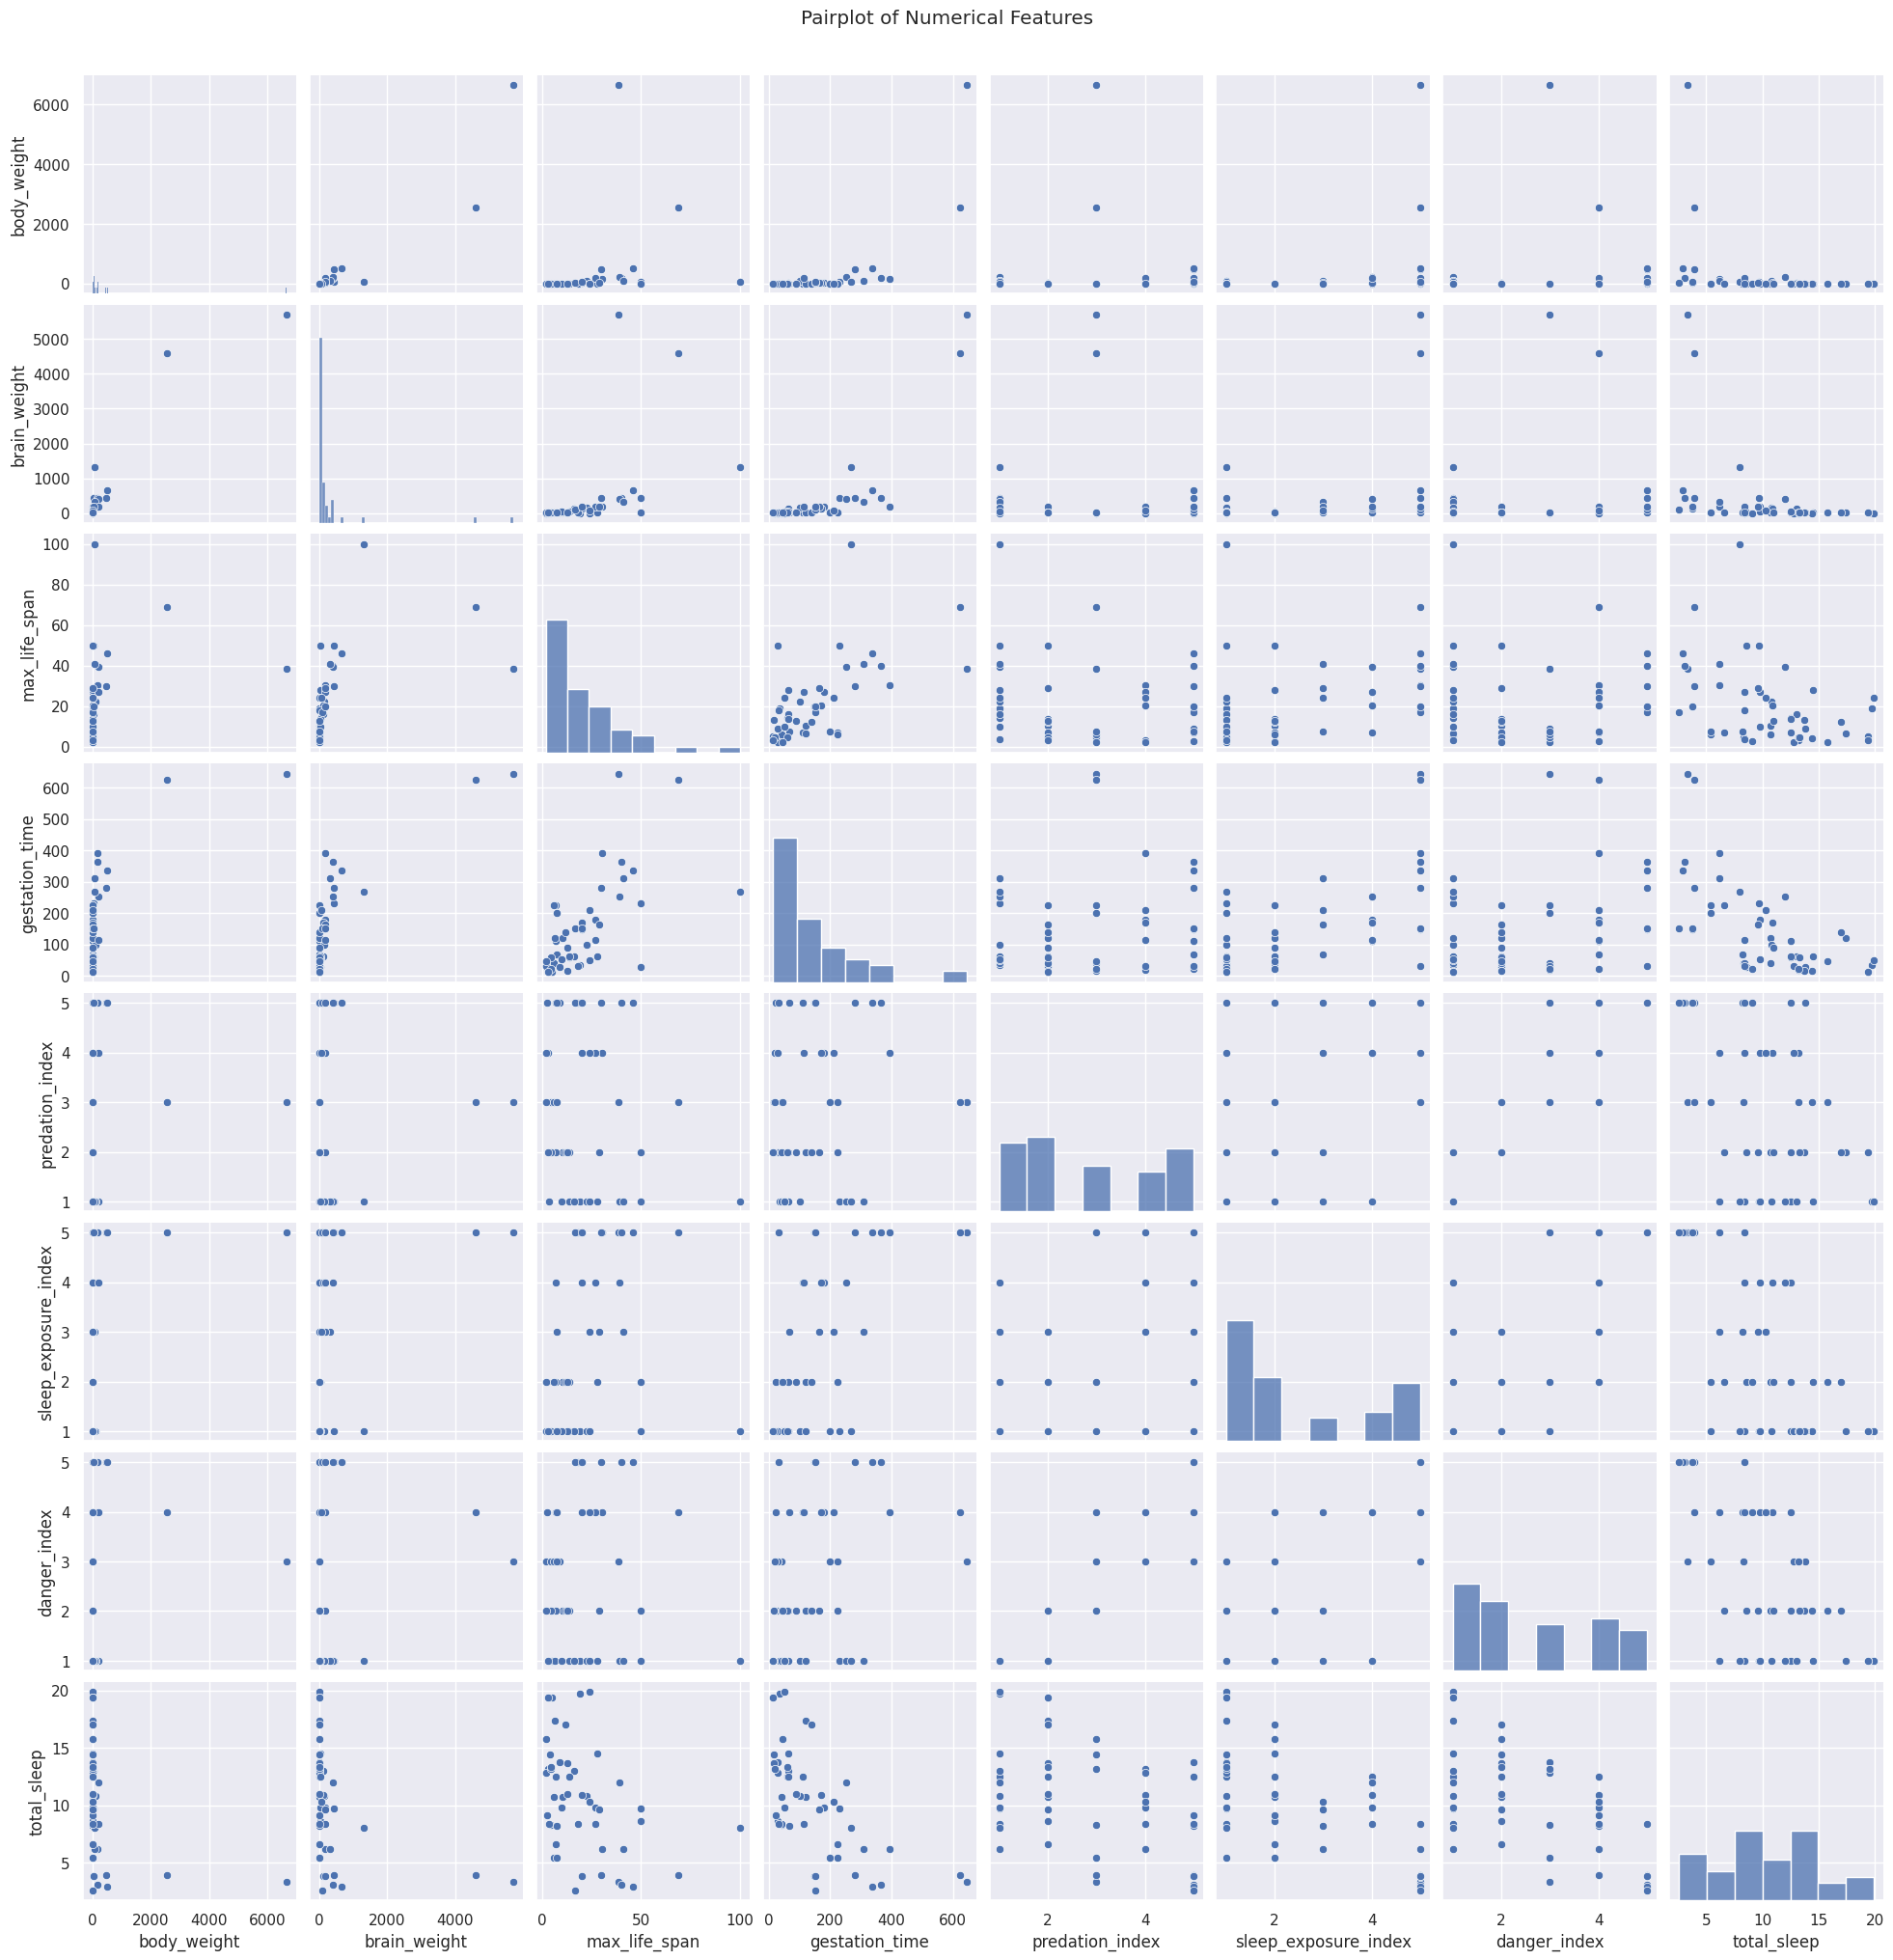

In [42]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Heatmap

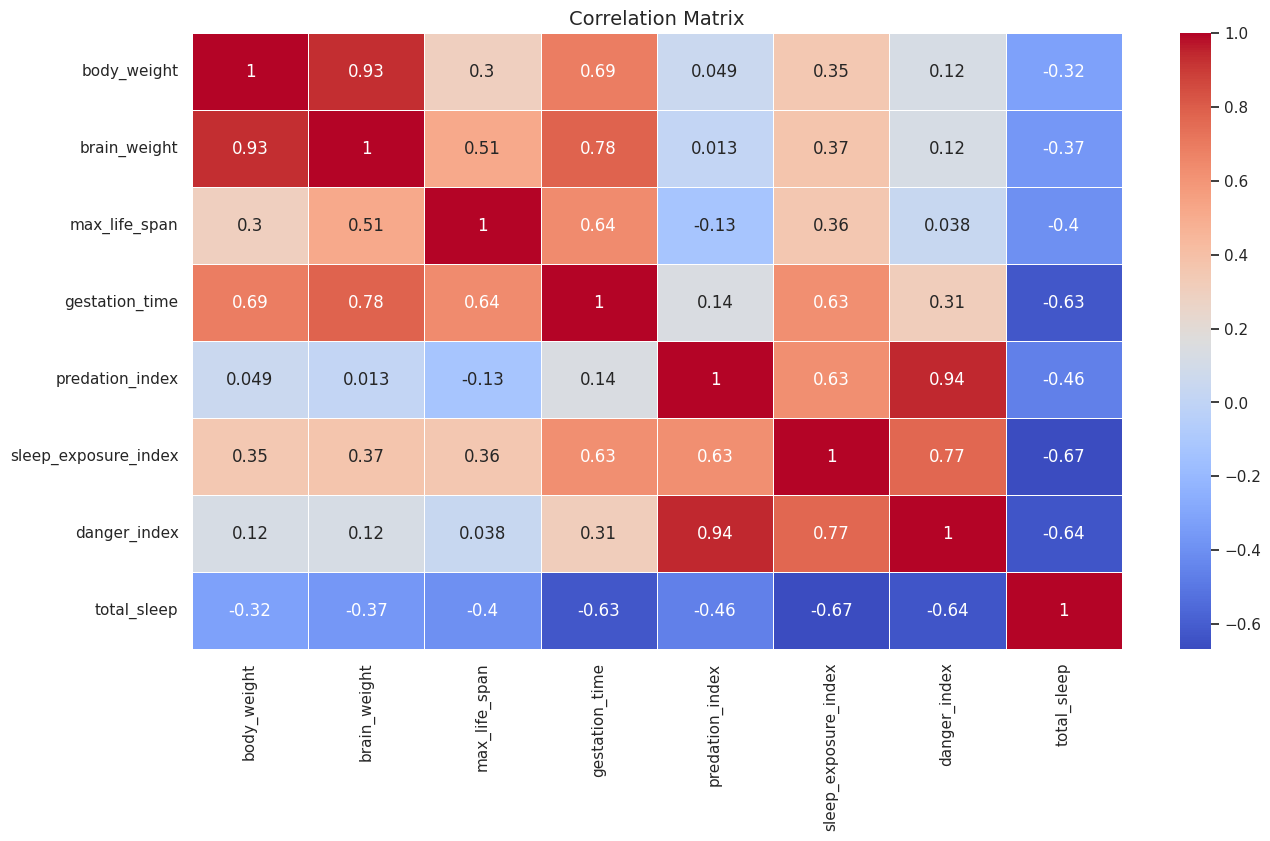

In [43]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Statistical Analysis